# Análisis Exploratorio: BiciMad 2022

Este notebook procesa y analiza los datos históricos de BiciMad 2022, el sistema de bicicletas públicas de Madrid. Los datos en crudo consisten en 12 archivos CSV mensuales (uno por cada mes del año) almacenados en la carpeta `2022_bicimad_RawData`, que contienen información detallada sobre 4+ millones de viajes realizados durante el año, incluyendo fecha/hora, duración, estaciones de origen y destino.

**Fuente:** [Empresa Municipal de Transportes de Madrid (EMT)](https://www.emtmadrid.es/)

**Dataset:** [Históricos de BiciMad 2017-2023](https://datos.emtmadrid.es/dataset/historicos-de-bicimad-2017_2023)

El objetivo es preparar estos datos para su posterior integración con información meteorológica, de tráfico y calendario laboral, permitiendo análisis integrados del transporte urbano madrileño.

### 0. Requirements

In [30]:
import os # Para manejo de rutas
import glob # Para manejo de ficheros
import pandas as pd # Para manejo de dataframes
import matplotlib.pyplot as plt
from pathlib import Path # Para manejo de rutas

### 0.1 Funciones Auxiliares

In [31]:
# Función para limpiar nombres de estaciones
def limpiar_nombre_estacion(nombre):
    """
    Convierte nombres del formato 'XX - Nombre' y 'XXX - Nombre A/B' a solo 'Nombre'
    También elimina sufijos A/B de estaciones que están en la misma ubicación
    """
    if pd.isna(nombre):
        return nombre
    
    # Si tiene formato "XX - Nombre"
    if ' - ' in nombre:
        partes = nombre.split(' - ', 1)
        prefijo = partes[0].strip()
        
        # Verificar si el prefijo es un número o número+letra (como 106a, 1a, etc.)
        if (prefijo.isdigit() or 
            (len(prefijo) > 1 and prefijo[:-1].isdigit() and prefijo[-1].isalpha())):
            
            nombre_limpio = partes[1].strip()
            
            # Si termina en " A" o " B", también quitarlo
            if nombre_limpio.endswith(' A') or nombre_limpio.endswith(' B'):
                nombre_limpio = nombre_limpio[:-2].strip()
            
            return nombre_limpio
    
    # Para nombres sin formato "XX - ", eliminar sufijos A/B directamente
    nombre_limpio = nombre.strip()
    if nombre_limpio.endswith(' A') or nombre_limpio.endswith(' B'):
        nombre_limpio = nombre_limpio[:-2].strip()
    
    return nombre_limpio

# Función para crear gráficos de violín
def crear_violin(ax, datos, color, titulo, xlabel):
    """Función auxiliar para crear gráficos de violín consistentes"""
    violin = ax.violinplot([datos], positions=[1], widths=[0.5])
    violin['bodies'][0].set_facecolor(color)
    violin['bodies'][0].set_alpha(0.7)
    ax.set_title(titulo)
    ax.set_ylabel('Duración (minutos)')
    ax.set_xlabel(xlabel)
    ax.set_xticks([1])
    ax.set_xticklabels(['trip_minutes'])
    ax.grid(True, alpha=0.3)


## 1. Carga de datos

En la carpeta `2022_bicimad` tenemos 12 archivos CSV que contienen los registros de viajes mes a mes. Nuestro objetivo en esta sección es concatenar todos ellos en un único Dataframe que unifique todos los viajes registrados en 2022. Para ello, primero hemos de asegurarnos que todos ellos tienen las mismas columnas.

In [32]:
DATA_DIR = '2022_bicimad_RawData'
files = sorted(glob.glob(os.path.join(DATA_DIR, 'trips_22_*.csv')))
print('Charged CSV files:', len(files))
files

Charged CSV files: 12


['2022_bicimad_RawData\\trips_22_01_January.csv',
 '2022_bicimad_RawData\\trips_22_02_February.csv',
 '2022_bicimad_RawData\\trips_22_03_March.csv',
 '2022_bicimad_RawData\\trips_22_04_April.csv',
 '2022_bicimad_RawData\\trips_22_05_May.csv',
 '2022_bicimad_RawData\\trips_22_06_June.csv',
 '2022_bicimad_RawData\\trips_22_07_July.csv',
 '2022_bicimad_RawData\\trips_22_08_August.csv',
 '2022_bicimad_RawData\\trips_22_09_September.csv',
 '2022_bicimad_RawData\\trips_22_10_October.csv',
 '2022_bicimad_RawData\\trips_22_11_November.csv',
 '2022_bicimad_RawData\\trips_22_12_December.csv']

In [33]:
# Diccionario: nombre de archivo -> lista de columnas (CSV con separador ';')
columnas = {Path(f).name: list(pd.read_csv(f, nrows=0, sep=';').columns) for f in files}

num_cols_per_file = [len(cols) for cols in columnas.values()]
print(num_cols_per_file)

[19, 18, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18]


+ Después de una exploracion visual rápida de los archivos CSV, detectamos que en los archivoss de enero, marzo, abril, mayo, junio y julio existe una columna que en los demás no: 'idTrip'. Como esta columna no aporta información relevante, la eliminaremos para facilitar la concatenacion de todos los datos en un único Dataframe

In [34]:
# Cargar cada mes y eliminar 'idTrip' si existe
dfs_mensuales = []
for ruta in files:
    df = pd.read_csv(ruta, sep=';')
    if 'idTrip' in df.columns:
        df = df.drop(columns=['idTrip'])
    dfs_mensuales.append(df)
print('DataFrames cargados:', len(dfs_mensuales))

C:\Users\josem\AppData\Local\Temp\ipykernel_10744\3252134346.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=';')
C:\Users\josem\AppData\Local\Temp\ipykernel_10744\3252134346.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=';')
C:\Users\josem\AppData\Local\Temp\ipykernel_10744\3252134346.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=';')
C:\Users\josem\AppData\Local\Temp\ipykernel_10744\3252134346.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=';')


DataFrames cargados: 12


In [35]:
# Concatenar todos los meses en un único DataFrame
df_bicimad2022 = pd.concat(dfs_mensuales, ignore_index=True)
print('Forma final:', df_bicimad2022.shape)
df_bicimad2022.head(10)

Forma final: (8288268, 18)


,fecha,idBike,fleet,trip_minutes,geolocation_unlock,address_unlock,unlock_date,locktype,unlocktype,geolocation_lock,address_lock,lock_date,station_unlock,dock_unlock,unlock_station_name,station_lock,dock_lock,lock_station_name
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,1718.00,1.00,16.28,"{'type': 'Point', 'coordinates': [-3.6714166, ...",NaN,2022-01-01T00:02:20,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688398, 4...",NaN,2022-01-01T00:18:37,200.00,3.00,Avenida de los Toreros,64.00,4.00,Plaza de la Independencia
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,7340.00,1.00,7.10,"{'type': 'Point', 'coordinates': [-3.6894193, ...",NaN,2022-01-01T00:07:53,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6993465, ...",NaN,2022-01-01T00:14:59,69.00,5.00,Antonio Maura,169.00,17.00,Manuel Silvela
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022-01-01,3861.00,1.00,0.48,"{'type': 'Point', 'coordinates': [-3.688822, 4...",NaN,2022-01-01T00:09:21,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688822, 4...",NaN,2022-01-01T00:09:50,73.00,21.00,Puerta del Ángel Caído,73.00,21.00,Puerta del Ángel Caído
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2022-01-01,7657.00,1.00,6.62,"{'type': 'Point', 'coordinates': [-3.6653055, ...",NaN,2022-01-01T00:09:52,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6657777, ...",NaN,2022-01-01T00:16:29,192.00,22.00,Marqués de Zafra,190.00,17.00,Parque Roma
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2022-01-01,6653.00,1.00,8.07,"{'type': 'Point', 'coordinates': [-3.6983055, ...",NaN,2022-01-01T00:09:57,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.7025024, ...",NaN,2022-01-01T00:18:01,183.00,3.00,Jaime el Conquistador,47.00,24.00,Jesús y María


### 1.2. Limpieza Preliminar de Datos

Antes de empezar con la comprensión general de los datosy un pre-procesado mas profundo, vamos a solucionar un problema que ya se ha identificado:
+ 1. Debido a un posible error externo en la construcción del fichero de datos, existen filas vacías intercaladas en el dataset. Eliminaremos todas.

In [36]:
# Eliminar filas vacías
filas_vacias = df_bicimad2022.isna().all(axis=1).sum()
df_bicimad2022 = df_bicimad2022.dropna(how='all').reset_index(drop=True)
print('Filas vacías eliminadas:', filas_vacias)

Filas vacías eliminadas: 4144134


## 2. Comprensión General de los datos

En esta sección exploraremos la estructura y características básicas del dataset

In [37]:
print('Dimensiones del DataFrame de registro de bicimad 2022:', df_bicimad2022.shape)
df_bicimad2022.head()

Dimensiones del DataFrame de registro de bicimad 2022: (4144134, 18)


,fecha,idBike,fleet,trip_minutes,geolocation_unlock,address_unlock,unlock_date,locktype,unlocktype,geolocation_lock,address_lock,lock_date,station_unlock,dock_unlock,unlock_station_name,station_lock,dock_lock,lock_station_name
0,2022-01-01,1718.00,1.00,16.28,"{'type': 'Point', 'coordinates': [-3.6714166, ...",NaN,2022-01-01T00:02:20,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688398, 4...",NaN,2022-01-01T00:18:37,200.00,3.00,Avenida de los Toreros,64.00,4.00,Plaza de la Independencia
1,2022-01-01,7340.00,1.00,7.10,"{'type': 'Point', 'coordinates': [-3.6894193, ...",NaN,2022-01-01T00:07:53,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6993465, ...",NaN,2022-01-01T00:14:59,69.00,5.00,Antonio Maura,169.00,17.00,Manuel Silvela
2,2022-01-01,3861.00,1.00,0.48,"{'type': 'Point', 'coordinates': [-3.688822, 4...",NaN,2022-01-01T00:09:21,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688822, 4...",NaN,2022-01-01T00:09:50,73.00,21.00,Puerta del Ángel Caído,73.00,21.00,Puerta del Ángel Caído
3,2022-01-01,7657.00,1.00,6.62,"{'type': 'Point', 'coordinates': [-3.6653055, ...",NaN,2022-01-01T00:09:52,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6657777, ...",NaN,2022-01-01T00:16:29,192.00,22.00,Marqués de Zafra,190.00,17.00,Parque Roma
4,2022-01-01,6653.00,1.00,8.07,"{'type': 'Point', 'coordinates': [-3.6983055, ...",NaN,2022-01-01T00:09:57,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.7025024, ...",NaN,2022-01-01T00:18:01,183.00,3.00,Jaime el Conquistador,47.00,24.00,Jesús y María


## 2.1 Problema de nomenclatura en los nombres de estaciones.

En nuestro dataset, los nombres de las estaciones de bicicletas se recogen en `unlock_station_name` y `lock_station_name`. 

Sin embargo, hemos detectado errores en el dataset. La manera de anotar los nombres de las estaciones cambió a lo largo del año, por lo que encontramos la misma estacion con dos nombres diferentes. Los dos formatos se diferencian en que uno tiene un número incluído y el otro no.

Por ejemplo, tenemos registros de la estación `96 - Cibeles` y de la estación `Cibeles`

Esto lo solucionaremos unificando los dos nombres. Nuestra preferencia será el formato sin número.

En la siguiente celda se muestra una tabla que permite visualizar el problema:

In [38]:
# Análisis del problema de nomenclatura de estaciones
print("=== PROBLEMA DE NOMENCLATURA DE ESTACIONES ===\n")

# Obtener todos los nombres únicos de estaciones (combinando salida y llegada)
todos_nombres = set()
todos_nombres.update(df_bicimad2022['unlock_station_name'].dropna().unique())
todos_nombres.update(df_bicimad2022['lock_station_name'].dropna().unique())

# Separar nombres con formato "XX - Nombre" vs solo "Nombre"
nombres_con_numero = []
nombres_sin_numero = []

for nombre in todos_nombres:
    if ' - ' in nombre and nombre.split(' - ')[0].isdigit():
        nombres_con_numero.append(nombre)
    else:
        nombres_sin_numero.append(nombre)

print(f"Estaciones con formato 'Número - Nombre': {len(nombres_con_numero)}")
print(f"Estaciones con formato solo 'Nombre': {len(nombres_sin_numero)}")

# Buscar estaciones que aparecen en ambos formatos
print("\nESTACIONES QUE APARECEN EN AMBOS FORMATOS:")
print("=" * 60)

duplicadas_encontradas = 0
for nombre_con_num in sorted(nombres_con_numero):
    # Extraer la parte del nombre sin el número
    nombre_sin_num = nombre_con_num.split(' - ', 1)[1]
    
    if nombre_sin_num in nombres_sin_numero:
        duplicadas_encontradas += 1
        print(f"{duplicadas_encontradas:2d}. '{nombre_con_num}' <-> '{nombre_sin_num}'")

if duplicadas_encontradas == 0:
    print("No se encontraron estaciones duplicadas con ambos formatos.")
    print("\nEjemplos de nombres con número:")
    for i, nombre in enumerate(sorted(nombres_con_numero)[:10], 1):
        print(f"  {i}. {nombre}")
    
    print("\nEjemplos de nombres sin número:")
    for i, nombre in enumerate(sorted(nombres_sin_numero)[:10], 1):
        print(f"  {i}. {nombre}")

print(f"\nTotal de estaciones duplicadas encontradas: {duplicadas_encontradas}")

=== PROBLEMA DE NOMENCLATURA DE ESTACIONES ===

Estaciones con formato 'Número - Nombre': 251
Estaciones con formato solo 'Nombre': 269

ESTACIONES QUE APARECEN EN AMBOS FORMATOS:
 1. '10 - Marqués de la Ensenada' <-> 'Marqués de la Ensenada'
 2. '100 - Palacio de Deportes' <-> 'Palacio de Deportes'
 3. '101 - Jorge Juan' <-> 'Jorge Juan'
 4. '102 - Velázquez' <-> 'Velázquez'
 5. '103 - Ortega y Gasset' <-> 'Ortega y Gasset'
 6. '104 - Castellana' <-> 'Castellana'
 7. '105 - Serrano' <-> 'Serrano'
 8. '107 - Columela' <-> 'Columela'
 9. '108 - Mártires Concepcionistas' <-> 'Mártires Concepcionistas'
10. '109 - Marqués de Salamanca' <-> 'Marqués de Salamanca'
11. '11 - San Andrés' <-> 'San Andrés'
12. '110 - Moncloa' <-> 'Moncloa'
13. '112 - Paseo de Moret' <-> 'Paseo de Moret'
14. '113 - Pintor Rosales' <-> 'Pintor Rosales'
15. '114 - Quintana' <-> 'Quintana'
16. '115 - Ferraz' <-> 'Ferraz'
17. '117 - Altamirano' <-> 'Altamirano'
18. '118 - Juan Martín' <-> 'Juan Martín'
19. '119 - Mén

#### **Solución del problema de nomenclatura**

Como hemos identificado que existen estaciones con doble nomenclatura (formato "Número - Nombre" vs solo "Nombre"), necesitamos unificar estos nombres para evitar que la misma estación aparezca como dos estaciones diferentes en nuestro análisis.

**Estaciones con sufijos A/B**

También encontramos estaciones con sufijos A y B que están en la misma ubicación. Algunos ejemplos:
- `106a - Colón A` y `106b - Colón B` 
- `111a - Arcipreste de Hita A` y `111b - Arcipreste de Hita B`
- `116a - Plaza de España A` y `116b - Plaza de España B`
- `1a - Puerta del Sol A` y `1b - Puerta del Sol B`
- `20a - Banco de España A`
- `25a - Plaza de Celenque A` y `25b - Plaza de Celenque B`
- `80a - Atocha A` y `80b - Atocha B`

Los sufijos A/B simplemente distinguen diferentes puntos de anclaje dentro de la misma zona. Como esencialmente se refieren a la misma ubicación, para nuestro análisis es mejor tratarlas como una sola estación.

La estrategia ideal sería apoyarnos en las columnas `station_unlock` y `station_lock`, que funcionan como IDs de las estaciones. Sin embargo, tras una exploración en profundidad del dataset se encontró que había IDs que tenían asignadas más de una estación, así como estaciones con más de un ID, lo cual imposibilita este enfoque.

**Estrategia de unificación:**
- Para todos los nombres que sigan el patrón "XX - Nombre", extraeremos únicamente la parte "Nombre"
- Eliminar sufijos A/B de los nombres de estaciones para unificar ubicaciones geográficamente equivalentes
- Esto unificará automáticamente las estaciones duplicadas bajo un solo nombre consistente
- Elegimos el formato sin número y sin sufijos porque representa mejor la ubicación real para el análisis

**Implementación:**

In [39]:

# Aplicar limpieza a las columnas de nombres de estaciones
print("Aplicando limpieza de nombres de estaciones...")

# Antes de la limpieza
estaciones_unlock_antes = df_bicimad2022['unlock_station_name'].nunique()
estaciones_lock_antes = df_bicimad2022['lock_station_name'].nunique()

# Limpiar nombres
df_bicimad2022['unlock_station_name'] = df_bicimad2022['unlock_station_name'].apply(limpiar_nombre_estacion)
df_bicimad2022['lock_station_name'] = df_bicimad2022['lock_station_name'].apply(limpiar_nombre_estacion)

# Reconvertir a categóricas para actualizar las categorías
df_bicimad2022['unlock_station_name'] = df_bicimad2022['unlock_station_name'].astype('category')
df_bicimad2022['lock_station_name'] = df_bicimad2022['lock_station_name'].astype('category')

# Después de la limpieza
estaciones_unlock_despues = df_bicimad2022['unlock_station_name'].nunique()
estaciones_lock_despues = df_bicimad2022['lock_station_name'].nunique()

print(f"Estaciones de salida - Antes: {estaciones_unlock_antes}, Después: {estaciones_unlock_despues}")
print(f"Estaciones de llegada - Antes: {estaciones_lock_antes}, Después: {estaciones_lock_despues}")
print(f"Reducción total: {estaciones_unlock_antes - estaciones_unlock_despues} estaciones unificadas")

print("\nLimpieza completada.")

Aplicando limpieza de nombres de estaciones...
Estaciones de salida - Antes: 519, Después: 253
Estaciones de llegada - Antes: 520, Después: 254
Reducción total: 266 estaciones unificadas

Limpieza completada.


+ El problema detectado en el dataset ha sido solucionado. De esta forma, las columnas `unlock_station_name` y `lock_station_name` ya nos sirven para realizar un análisis de uso por estación

## 2.2 Selección de variables y tipado de datos

In [40]:
print('Columnas del dataset de biciMadrid:')
for col in df_bicimad2022.columns:
    print(col)

Columnas del dataset de biciMadrid:
fecha
idBike
fleet
trip_minutes
geolocation_unlock
address_unlock
unlock_date
locktype
unlocktype
geolocation_lock
address_lock
lock_date
station_unlock
dock_unlock
unlock_station_name
station_lock
dock_lock
lock_station_name


En este dataset existen algunas columnas que podemos eliminar ya que o bien no aportan informacion relevante a nuestro análisis, o bien su información está ya implicita en otras columnas.

+ `fecha`, `lock_date`: Las eliminamos porque para extraer datos acerca de la hora y diración de cada viaje nos llega con las variables `unlock_date` y `trip_minutes` 
+ `IdBike` y `Fleet`: Identificar qué bicicleta se utilizó en cada viaje no es importante en nuestro análisis.
+ `geolocation_lock` y `geolocation_unlock`: Contienen las coordenadas de las estaciones de inicio y fin de viaje, no aportan información nueva relevante para nuestro análisis. Nos bastará con utilizar los nombres de las estaciones. Además, requieren un pre-procesado bastante complejo porque vienen en un formato de diccionario.
+ `adress_unlock` y `adress_lock`: Las direcciones nuevamente no nos resultan útiles teniendo ya los nombres de las estaciones.
+ `station_lock` y `station_unlock`: Los IDs numéricos de las estaciones. Cpmo hemos visto en la subsección anterior, ni son correctos ni aportan información.
+ `dock_lock` y `dock_unlock`: Dentro de una estación, hay un número de puertos de enganche. Esta información no es relevante en nuestro análisis.

In [41]:
# Eliminar columnas no necesarias
columnas_a_eliminar = [
    'fecha', 'lock_date',
    'idBike', 'fleet',
    'geolocation_lock', 'geolocation_unlock',
    'address_unlock', 'address_lock',
    'station_unlock', 'station_lock',
    'dock_unlock', 'dock_lock'
]

df_bicimad2022 = df_bicimad2022.drop(columns=columnas_a_eliminar, errors='ignore')
print('Operación de eliminación realizada.')
print('Dimensiones tras eliminar columnas no necesarias:', df_bicimad2022.shape)
df_bicimad2022.head()


Operación de eliminación realizada.
Dimensiones tras eliminar columnas no necesarias: (4144134, 6)


,trip_minutes,unlock_date,locktype,unlocktype,unlock_station_name,lock_station_name
0,16.28,2022-01-01T00:02:20,STATION,STATION,Avenida de los Toreros,Plaza de la Independencia
1,7.10,2022-01-01T00:07:53,STATION,STATION,Antonio Maura,Manuel Silvela
2,0.48,2022-01-01T00:09:21,STATION,STATION,Puerta del Ángel Caído,Puerta del Ángel Caído
3,6.62,2022-01-01T00:09:52,STATION,STATION,Marqués de Zafra,Parque Roma
4,8.07,2022-01-01T00:09:57,STATION,STATION,Jaime el Conquistador,Jesús y María


### 2.2 Tipado de Datos

Veamos primero qué tipo de dato tiene asociada cada una de las variables tras la lectura de los archivos.

In [42]:
for col, dtype in df_bicimad2022.dtypes.items():
    print(f"Columna: {col} | Tipo de dato: {dtype}")

Columna: trip_minutes | Tipo de dato: float64
Columna: unlock_date | Tipo de dato: object
Columna: locktype | Tipo de dato: object
Columna: unlocktype | Tipo de dato: object
Columna: unlock_station_name | Tipo de dato: category
Columna: lock_station_name | Tipo de dato: category


+ `trip_minutes`: El tipo correcto será `int`
+ `unlock_date`: Hemos de pasarlo a `datetime`
+ `locktype`, `unlocktype`, `unlock_station_name`, `lock_station_name`: Todas ellas son columnas de tipo `category`.


In [43]:
# Convertir trip_minutes a int)
df_bicimad2022['trip_minutes'] = pd.to_numeric(df_bicimad2022['trip_minutes'], errors='coerce')

# Convertir unlock_date a datetime (conservando fecha y hora)
df_bicimad2022['unlock_date'] = pd.to_datetime(df_bicimad2022['unlock_date'], errors='coerce')

# Convertir columnas categóricas
columnas_categoricas = ['locktype', 'unlocktype', 'unlock_station_name', 'lock_station_name']
for col in columnas_categoricas:
    if col in df_bicimad2022.columns:
        df_bicimad2022[col] = df_bicimad2022[col].astype('category')

print("Tipado completado. Verificando tipos:")
for col, dtype in df_bicimad2022.dtypes.items():
    print(f"Columna: {col} | Tipo de dato: {dtype}")

Tipado completado. Verificando tipos:
Columna: trip_minutes | Tipo de dato: float64
Columna: unlock_date | Tipo de dato: datetime64[ns]
Columna: locktype | Tipo de dato: category
Columna: unlocktype | Tipo de dato: category
Columna: unlock_station_name | Tipo de dato: category
Columna: lock_station_name | Tipo de dato: category


## 3. Transformación y Limpieza
En esta sección preparamos los datos para el análisis identificando y tratando duplicados, valores faltantes y anomalías que puedan afectar la calidad del análisis posterior.

### 3.1 Eliminación de columnas sin variabilidad

Las columnas `locktype` y `unlocktype` indican el tipo de estación donde se inicia y finaliza cada viaje. Al analizar su distribución, observamos que prácticamente todos los registros corresponden al tipo 'STATION', por lo que estas columnas no aportan información discriminante para nuestro análisis.

In [44]:
# Recuento de registros por categoría en locktype
print("Recuento de registros por categoría en 'locktype':")
recuento_lock = df_bicimad2022['locktype'].value_counts()
porcentaje_lock = df_bicimad2022['locktype'].value_counts(normalize=True) * 100
for categoria, cantidad in recuento_lock.items():
    print(f"  {categoria}: {cantidad:,} registros ({porcentaje_lock[categoria]:.1f}%)")

print("\nRecuento de registros por categoría en 'unlocktype':")
recuento_unlock = df_bicimad2022['unlocktype'].value_counts()
porcentaje_unlock = df_bicimad2022['unlocktype'].value_counts(normalize=True) * 100
for categoria, cantidad in recuento_unlock.items():
    print(f"  {categoria}: {cantidad:,} registros ({porcentaje_unlock[categoria]:.1f}%)")


# Eliminar columnas locktype y unlocktype
df_bicimad2022 = df_bicimad2022.drop(columns=['locktype', 'unlocktype'])
print(f"\nColumnas 'locktype' y 'unlocktype' eliminadas.")
print(f"Dimensiones finales: {df_bicimad2022.shape}")

Recuento de registros por categoría en 'locktype':
  STATION: 4,124,227 registros (99.5%)
  FREE: 19,907 registros (0.5%)

Recuento de registros por categoría en 'unlocktype':
  STATION: 4,127,342 registros (99.6%)
  FREE: 16,792 registros (0.4%)

Columnas 'locktype' y 'unlocktype' eliminadas.
Dimensiones finales: (4144134, 4)


### 3.2 Valores Duplicados

In [45]:
# Mostrar duplicados en df_bicimad2022
total = len(df_bicimad2022)
n_duplicados = df_bicimad2022.duplicated().sum()
print(f'Total filas: {total}')
print(f'Filas duplicadas (duplicated()): {n_duplicados}')

# Mostrar todas las ocurrencias de filas duplicadas (keep=False)
dup_all = df_bicimad2022[df_bicimad2022.duplicated(keep=False)]
print(f'Filas que pertenecen a algún grupo duplicado: {len(dup_all)}')
print(f'% de filas que pertenecen a algún grupo duplicado: {len(dup_all) / total:.2%}')

# Mostrar ejemplos de duplicados 
print('Ejemplos de filas duplicadas:')
display(dup_all.sort_values(by=df_bicimad2022.columns.tolist()).head(20))


Total filas: 4144134
Filas duplicadas (duplicated()): 70409
Filas que pertenecen a algún grupo duplicado: 140814
% de filas que pertenecen a algún grupo duplicado: 3.40%
Ejemplos de filas duplicadas:


,trip_minutes,unlock_date,unlock_station_name,lock_station_name
1190444,0.00,2022-05-09 20:09:24,Jacinto Benavente,Jacinto Benavente
1190445,0.00,2022-05-09 20:09:24,Jacinto Benavente,Jacinto Benavente
1323041,0.00,2022-05-15 01:07:20,Plaza de San Miguel,Avenida de los Toreros
1323043,0.00,2022-05-15 01:07:20,Plaza de San Miguel,Avenida de los Toreros
1275690,0.02,2022-05-12 19:20:40,INEF,Paseo de Moret
1275691,0.02,2022-05-12 19:20:40,INEF,Paseo de Moret
1203165,0.03,2022-05-10 12:05:17,Niño Jesús,Niño Jesús
1203167,0.03,2022-05-10 12:05:17,Niño Jesús,Niño Jesús
1211534,0.03,2022-05-10 17:14:10,San Hermenegildo,San Hermenegildo
1211535,0.03,2022-05-10 17:14:10,San Hermenegildo,San Hermenegildo


+ Un 3.4 % de las filas pertenecen a grupos duplicados. Si bien no es un porcentaje que invalide el dataset, representa un número considerable de registros.

+ Según vemos en los ejemplos hay viajes que se han registrado dos veces de manera consecutiva en el datataset. Dejaremos un único registro por viaje.

In [46]:
n_duplicados_antes = df_bicimad2022.duplicated().sum()
df_bicimad2022 = df_bicimad2022.drop_duplicates()
print(f"Duplicados eliminados: {n_duplicados_antes}")
print("Dimensiones tras eliminar duplicados:", df_bicimad2022.shape)

Duplicados eliminados: 70409
Dimensiones tras eliminar duplicados: (4073725, 4)


### 3.3 Valores Faltantes

In [47]:
df_bicimad2022.isnull().sum()

trip_minutes               0
unlock_date                0
unlock_station_name    16791
lock_station_name      19906
dtype: int64

Como observamos, solo las columnas de nombres de estaciones (`unlock_station_name` y `lock_station_name`) tienen valores faltantes:

- **unlock_station_name**: 16,791 valores faltantes
- **lock_station_name**: 19,906 valores faltantes

Considerando que nuestro dataset tiene más de 4 millones de registros, estos valores faltantes representan menos del 0.5% del total. Dado que son relativamente pocos y eliminando estos registros perderiamos información valiosa de los viajes, decidimos mantenerlos y asignarles la categoría 'Unknown' para distinguirlos en el análisis.

In [48]:
# Rellenar valores faltantes con 'Unknown'
valores_faltantes_unlock_antes = df_bicimad2022['unlock_station_name'].isnull().sum()
valores_faltantes_lock_antes = df_bicimad2022['lock_station_name'].isnull().sum()

# Añadir 'Unknown' a las categorías existentes antes de rellenar
df_bicimad2022['unlock_station_name'] = df_bicimad2022['unlock_station_name'].cat.add_categories(['Unknown'])
df_bicimad2022['lock_station_name'] = df_bicimad2022['lock_station_name'].cat.add_categories(['Unknown'])

# Rellenar con 'Unknown'
df_bicimad2022['unlock_station_name'] = df_bicimad2022['unlock_station_name'].fillna('Unknown')
df_bicimad2022['lock_station_name'] = df_bicimad2022['lock_station_name'].fillna('Unknown')

print(f"Valores faltantes rellenados:")
print(f"- unlock_station_name: {valores_faltantes_unlock_antes} registros")
print(f"- lock_station_name: {valores_faltantes_lock_antes} registros")

# Verificar que no quedan valores faltantes
print("\nVerificación final de valores faltantes:")
print(df_bicimad2022.isnull().sum())

Valores faltantes rellenados:
- unlock_station_name: 16791 registros
- lock_station_name: 19906 registros

Verificación final de valores faltantes:
trip_minutes           0
unlock_date            0
unlock_station_name    0
lock_station_name      0
dtype: int64


### 3.4 Detección de Anomalías

La única variable numérica en nuestro dataset es `trip_minutes` (duración del viaje en minutos). Es importante identificar valores anómalos que puedan distorsionar nuestro análisis, como viajes excesivamente largos o cortos que no representen un uso típico del sistema de bicicletas.

In [49]:
# Configurar pandas para mostrar dos decimales y desactivar notación científica
pd.options.display.float_format = '{:.2f}'.format

# Describir la columna 'trip_minutes'
print(df_bicimad2022['trip_minutes'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.996]))


count   4073725.00
mean         22.52
std         284.24
min       -8677.33
1%            0.13
5%            0.23
25%           5.90
50%          10.73
75%          16.53
95%          30.07
99%          53.25
99.5%        58.57
99.6%        59.67
max       41795.60
Name: trip_minutes, dtype: float64


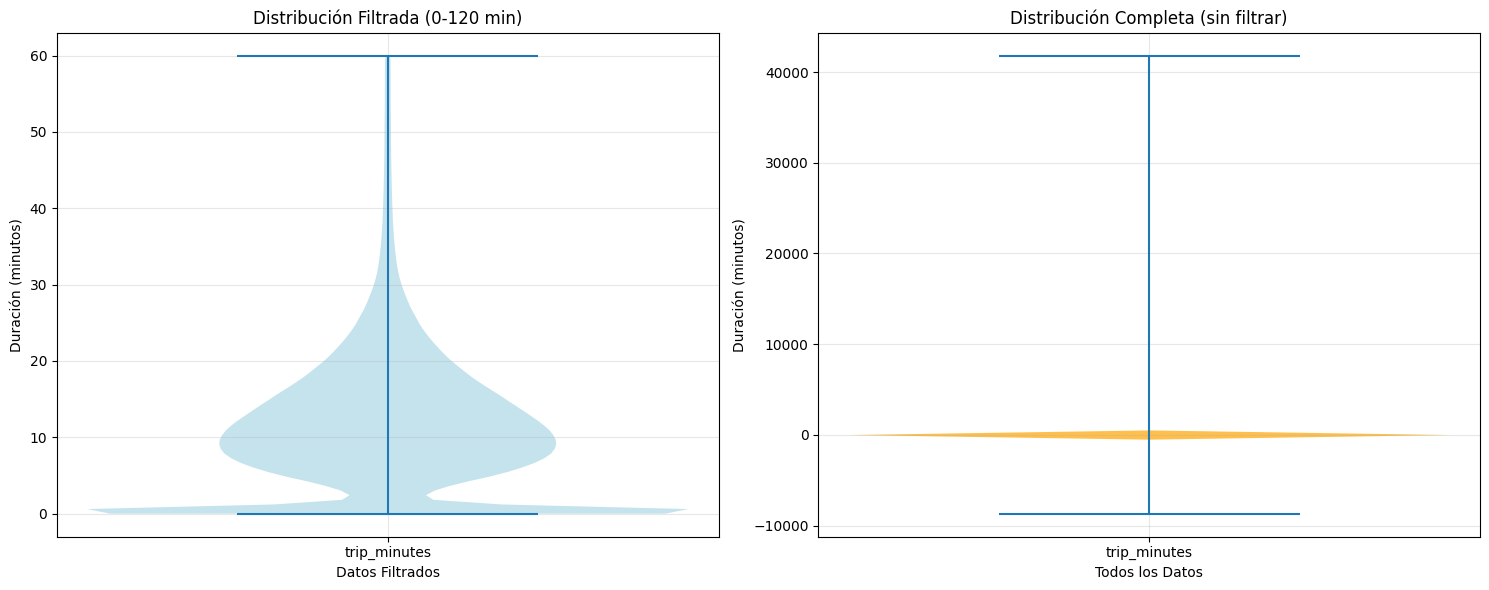

Registros filtrados (0-120 min): 4,057,469
Registros totales: 4,073,725
Registros excluidos: 16,256 (0.40%)


In [50]:
# Preparar datos
datos_completos = df_bicimad2022['trip_minutes'].dropna()
datos_filtrados = df_bicimad2022['trip_minutes'][(df_bicimad2022['trip_minutes'] >= 0) & 
                                                 (df_bicimad2022['trip_minutes'] <= 120)]

# Crear gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

crear_violin(ax1, datos_filtrados, 'lightblue', 
            'Distribución Filtrada (0-120 min)', 'Datos Filtrados')
crear_violin(ax2, datos_completos, 'orange', 
            'Distribución Completa (sin filtrar)', 'Todos los Datos')

plt.tight_layout()
plt.show()

print(f"Registros filtrados (0-120 min): {len(datos_filtrados):,}")
print(f"Registros totales: {len(datos_completos):,}")
print(f"Registros excluidos: {len(datos_completos) - len(datos_filtrados):,} ({((len(datos_completos) - len(datos_filtrados))/len(datos_completos)*100):.2f}%)")

#### **Interpretación de los gráficos de violín**

Los gráficos de violín revelan claramente la presencia de **valores anómalos** en la variable `trip_minutes`:

**Gráfico izquierdo (0-120 min):**
- Muestra la distribución real de viajes normales
- Forma típica con concentración en 5-20 minutos (uso habitual de bicicletas urbanas)
- Permite visualizar la verdadera estructura de los datos de movilidad

**Gráfico derecho (sin filtrar):**
- Completamente comprimido debido a valores extremos
- Escala distorsionada que impide ver la distribución real
- Demuestra visualmente el impacto de las anomalías

**Análisis basado en percentiles anteriores:**
- El **99% de viajes** duran menos de 53.2 minutos (percentil 99)
- La **mediana** es 10.7 minutos (viaje típico urbano)
- Solo el **0.40% de datos** están fuera del rango 0-120 minutos

**Anomalías identificadas:**
1. **1,704 valores negativos**: Errores del sistema de registro (hasta -8,677 minutos)
2. **14,552 viajes > 8 horas**: Técnicamente imposibles para uso normal de bicicletas (máximo: 696 horas)

## 3.6 Manejo de Anomalías

Se reemplazarán los valores anómalos (negativos y > 8 horas) con la media de los datos válidos para mantener la estructura del dataset.

In [51]:
# Manejo sencillo de anomalías: reemplazar con la media
datos_validos = df_bicimad2022[(df_bicimad2022['trip_minutes'] >= 0) & 
                               (df_bicimad2022['trip_minutes'] <= 480)]['trip_minutes']
media_validos = datos_validos.mean()

# Crear dataset limpio
df_limpio = df_bicimad2022.copy()
anomalias = (df_limpio['trip_minutes'] < 0) | (df_limpio['trip_minutes'] > 480)
df_limpio.loc[anomalias, 'trip_minutes'] = media_validos

print(f"Anomalías corregidas: {anomalias.sum():,}")

Anomalías corregidas: 16,256


## 4. Análisis Descriptivo

### 4.1 Variable Numérica: Duración de Viajes (trip_minutes)

In [52]:
# Análisis descriptivo de trip_minutes usando el dataset limpio
print("=== ESTADÍSTICAS DESCRIPTIVAS - DURACIÓN DE VIAJES ===")
print("\nDataset limpio (anomalías corregidas):")
print(df_limpio['trip_minutes'].describe())

=== ESTADÍSTICAS DESCRIPTIVAS - DURACIÓN DE VIAJES ===

Dataset limpio (anomalías corregidas):
count   4073725.00
mean         12.15
std           9.70
min           0.00
25%           5.92
50%          10.73
75%          16.42
max          59.98
Name: trip_minutes, dtype: float64


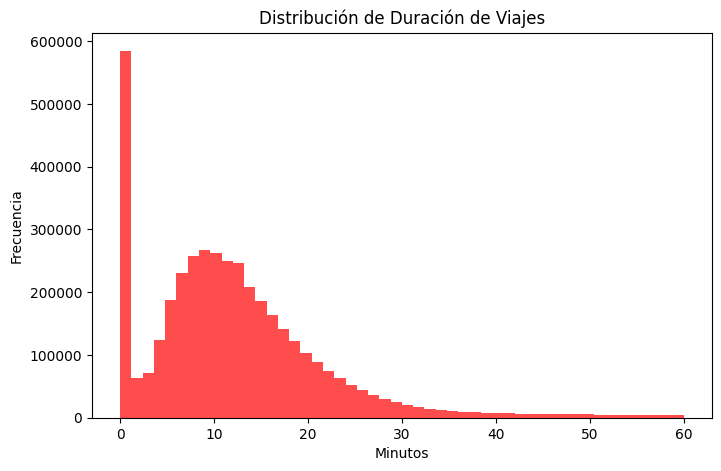

Viajes mostrados: 4,073,725 (0-30 min)


In [53]:
# Gráfico simple de distribución
import matplotlib.pyplot as plt

datos_grafico = df_limpio['trip_minutes']

plt.figure(figsize=(8, 5))
plt.hist(datos_grafico, bins=50, color='red', alpha=0.7)
plt.title('Distribución de Duración de Viajes')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

print(f"Viajes mostrados: {len(datos_grafico):,} (0-30 min)")


#### **Insights:**
- **Patrón de uso urbano**: La media de 12.1 minutos indica viajes cortos propios del transporte urbano
- **Concentración en trayectos breves**: La mediana de 10.7 minutos confirma que la mayoría utiliza BiciMad para trayectos rápidos
- **Distribución típica**: El histograma muestra concentración en los primeros 5-15 minutos, confirmando el uso para conexiones de transporte
- **Complemento al transporte público**: Los datos sugieren que BiciMad funciona como enlace entre diferentes medios de transporte

### 4.2 Variables Categóricas: Estaciones de Origen y Destino

In [54]:
# Análisis descriptivo de estaciones
print("=== ANÁLISIS DE ESTACIONES ===")

# Contar estaciones únicas
estaciones_salida = df_limpio['unlock_station_name'].nunique()
estaciones_llegada = df_limpio['lock_station_name'].nunique()

print(f"\nNúmero total de estaciones:")
print(f"- Estaciones de origen: {estaciones_salida}")
print(f"- Estaciones de destino: {estaciones_llegada}")

# Análisis de uso por estación de salida
print(f"\n=== TOP 5 ESTACIONES DE ORIGEN MÁS UTILIZADAS ===")
top_salidas = df_limpio['unlock_station_name'].value_counts().head(5)
for i, (estacion, viajes) in enumerate(top_salidas.items(), 1):
    porcentaje = (viajes / len(df_limpio)) * 100
    print(f"{i:2d}. {estacion[:50]}: {viajes:,} viajes ({porcentaje:.2f}%)")

print(f"\n=== TOP 5 ESTACIONES DE DESTINO MÁS UTILIZADAS ===")
top_llegadas = df_limpio['lock_station_name'].value_counts().head(5)
for i, (estacion, viajes) in enumerate(top_llegadas.items(), 1):
    porcentaje = (viajes / len(df_limpio)) * 100
    print(f"{i:2d}. {estacion[:50]}: {viajes:,} viajes ({porcentaje:.2f}%)")

=== ANÁLISIS DE ESTACIONES ===

Número total de estaciones:
- Estaciones de origen: 254
- Estaciones de destino: 255

=== TOP 5 ESTACIONES DE ORIGEN MÁS UTILIZADAS ===
 1. Plaza de la Cebada: 46,496 viajes (1.14%)
 2. Plaza de Lavapiés: 43,830 viajes (1.08%)
 3. Fernando el Católico: 42,653 viajes (1.05%)
 4. Segovia 45: 38,603 viajes (0.95%)
 5. Marqués de Vadillo: 36,224 viajes (0.89%)

=== TOP 5 ESTACIONES DE DESTINO MÁS UTILIZADAS ===
 1. Plaza de la Cebada: 46,894 viajes (1.15%)
 2. Plaza de Lavapiés: 43,110 viajes (1.06%)
 3. Fernando el Católico: 43,050 viajes (1.06%)
 4. Marqués de Vadillo: 39,497 viajes (0.97%)
 5. Segovia 45: 39,166 viajes (0.96%)


In [55]:
# Análisis más detallado de la distribución de uso
print(f"\n=== ANÁLISIS DE DISTRIBUCIÓN DE USO ===")

# Estadísticas de distribución para estaciones de salida
stats_salida = df_limpio['unlock_station_name'].value_counts()
print(f"Estadísticas de uso por estación de SALIDA:")
print(f"- Media de viajes por estación: {stats_salida.mean():.0f}")
print(f"- Mediana de viajes por estación: {stats_salida.median():.0f}")
print(f"- Estación menos usada: {stats_salida.min()} viajes")
print(f"- Estación más usada: {stats_salida.max():,} viajes")

# Distribución por cuartiles
print(f"\nDistribución por cuartiles (salida):")
print(f"- 25% de estaciones tienen ≤ {stats_salida.quantile(0.25):.0f} viajes")
print(f"- 50% de estaciones tienen ≤ {stats_salida.quantile(0.50):.0f} viajes") 
print(f"- 75% de estaciones tienen ≤ {stats_salida.quantile(0.75):.0f} viajes")

# Concentración del uso
total_viajes = len(df_limpio)
top_10_percent = int(0.1 * len(stats_salida))
viajes_top_10_percent = stats_salida.head(top_10_percent).sum()
concentracion = (viajes_top_10_percent / total_viajes) * 100

print(f"\nConcentración del uso:")
print(f"- Top 10% de estaciones (≈{top_10_percent} estaciones) concentran {concentracion:.1f}% de los viajes")
print(f"- Los demás 90% de estaciones manejan {100-concentracion:.1f}% de los viajes")


=== ANÁLISIS DE DISTRIBUCIÓN DE USO ===
Estadísticas de uso por estación de SALIDA:
- Media de viajes por estación: 16038
- Mediana de viajes por estación: 15008
- Estación menos usada: 2556 viajes
- Estación más usada: 46,496 viajes

Distribución por cuartiles (salida):
- 25% de estaciones tienen ≤ 10186 viajes
- 50% de estaciones tienen ≤ 15008 viajes
- 75% de estaciones tienen ≤ 19950 viajes

Concentración del uso:
- Top 10% de estaciones (≈25 estaciones) concentran 20.0% de los viajes
- Los demás 90% de estaciones manejan 80.0% de los viajes



**Insights:**
- La red de BiciMad presenta una distribución **relativamente equilibrada** 
- El top 10% de estaciones concentra solo el 20% de los viajes (distribución balanceada)
- La mediana (15,008 viajes) está cerca de la media (16,038), indicando simetría
- Incluso la estación menos usada registra 2,556 viajes, lo que indica un uso cconsistente en toda la red

## 5. Ingeniería de variables


En esta sección crearemos variables temporales para facilitar la integración con otros datasets.

- Derivamos 'fecha' (YYYY-MM-DD) y 'hora' (0–23) a partir de 'unlock_date'.
- Para el cálculo, 'unlock_date' se renombra temporalmente a 'fecha_hora'; después se elimina 'fecha_hora' y mantenemos solo 'fecha' y 'hora'.
- 'hora' usa el rango 0–23 para alinearse con el dataset de Tráfico.
- Objetivo: disponer de claves comunes [fecha, hora] para uniones con Tráfico, Meteorología y Calendario.

In [56]:
# Renombrar la columna actual de fecha
df_limpio = df_limpio.rename(columns={'unlock_date': 'fecha_hora'})

# Crear nueva columna fecha (solo la parte de fecha, sin hora)
df_limpio['fecha'] = df_limpio['fecha_hora'].dt.date

# Convertir a tipo fecha (datetime64[ns])
df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha'])

# Crear columna hora (0–23) para integración con Tráfico
_df_hora = df_limpio['fecha_hora'].dt.hour
# Asegurar tipo entero simple
_df_hora = _df_hora.astype('int64')
df_limpio['hora'] = _df_hora

# Eliminar fecha_hora (ya separada en 'fecha' y 'hora')
df_limpio = df_limpio.drop(columns=['fecha_hora'])

del _df_hora

print("Variables temporales creadas y normalizadas:")
print(f"- fecha: {df_limpio['fecha'].dtype} (formato fecha)")
print(f"- hora: {df_limpio['hora'].dtype} (0–23)")

Variables temporales creadas y normalizadas:
- fecha: datetime64[ns] (formato fecha)
- hora: int64 (0–23)


## Guardar los datos limpios en un nuevo CSV

In [59]:
df_limpio.rename(columns={'fecha': 'Dia'}, inplace=True)
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4073725 entries, 0 to 4144133
Data columns (total 5 columns):
 #   Column               Dtype         
---  ------               -----         
 0   trip_minutes         float64       
 1   unlock_station_name  category      
 2   lock_station_name    category      
 3   Dia                  datetime64[ns]
 4   hora                 int64         
dtypes: category(2), datetime64[ns](1), float64(1), int64(1)
memory usage: 139.9 MB


In [60]:
df_limpio.to_csv('2022_bicimad_CleanData/2022_bicimad_cleaned.csv', index=False)

## Resumen Final

Este análisis exploratorio ha procesado exitosamente los datos oficiales de BiciMad 2022, transformando un dataset complejo en información estructurada y lista para análisis posteriores.

**Resultados del EDA:**
- **Dataset final**: 4+ millones de viajes con 5 variables esenciales
- **Calidad de datos**: Anomalías corregidas, duplicados eliminados, valores faltantes tratados
- **Variables temporales**: Separación funcional de fecha y hora para facilitar cruces con otros datasets
- **Red de estaciones**: 258 ubicaciones unificadas con nomenclatura consistente

**Capacidades analíticas obtenidas:**
- Análisis temporal hora a hora de patrones de uso
- Distribución espacial por estaciones de origen/destino  
- Duración de viajes con distribución urbana típica (media: 12.1 min)
- Base sólida para integración con datos meteorológicos, tráfico y calendario laboral

El dataset limpio permitirá análisis integrados del ecosistema de transporte madrileño con alta granularidad temporal y espacial.